# 16. Most aplikacyjny: Titanic i Tips

Ten notebook jest **opcjonalnym mostem** między częścią tablicową a ćwiczeniami/projektem.

Wykład główny warto nadal prowadzić na małych liczbach, bo wtedy studenci widzą ręcznie:

$$
probability \rightarrow odds \rightarrow log(odds) \rightarrow X\beta \rightarrow \sigma(X\beta)
$$

Dopiero potem pokazujemy małe realne zbiory danych:

- **Titanic**: klasyfikacja binarna, odds ratio, regresja logistyczna, ROC/AUC, leakage.
- **Tips**: regresja liniowa, klasyfikacja po progu, threshold tuning, leakage.

Dane są zapisane lokalnie w katalogu `data/`, aby notebook działał bez internetu. W starszych notebookach pojawiało się `sns.load_dataset("titanic")` i `sns.load_dataset("tips")`; to jest wygodne, ale w środowisku bez cache wymaga pobrania danych online.

## Jak czytać ten notebook?

To jest notebook **opcjonalny**: pokazuje te same idee na popularnych danych `Titanic` i `Tips`.

Najważniejsze przejścia:

1. Titanic: tabela 2×2 → odds ratio → logistic regression.
2. Titanic: probability → threshold → confusion matrix → ROC/AUC.
3. Titanic: leakage przez `alive`.
4. Tips: regresja liniowa → klasyfikacja `large_tip` → leakage przez `tip`.
5. Regularizacja: L1 i sztuczne cechy szumowe.

Równoległe wyjaśnienia:

- [10 — odds, log-odds, OR, testy](10_odds_log_odds_or_fisher_chisquare_wald_v6_statsmodels_free_executed.ipynb)
- [11 — logistic regression i likelihood](11_logistic_regression_likelihood_v6_executed.ipynb)
- [13 — ROC/AUC i threshold](13_roc_auc_thresholds_v6_executed.ipynb)
- [14 — regularization](14_regularization_ridge_lasso_elasticnet_v6_executed.ipynb)
- [99 — companion: ROC/threshold toy](99_companion_roc_threshold_toy_v6_5.ipynb)

### Importy i dane

Notebook próbuje wczytać lokalne pliki `seaborn_titanic.csv` i `seaborn_tips.csv`. To jest bezpieczniejsze niż `sns.load_dataset(...)`, bo na zajęciach internet może nie działać.

Jeśli uruchamiasz notebook poza paczką, upewnij się, że pliki danych są w folderze `data` albo `../data`.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    r2_score, mean_squared_error, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

pd.set_option("display.precision", 4)
np.random.seed(42)

def find_data_file(filename):
    candidates = [
        Path("../data") / filename,
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Nie znaleziono {filename}. Sprawdzone lokalizacje: {candidates}")

titanic = pd.read_csv(find_data_file("seaborn_titanic.csv"))
tips = pd.read_csv(find_data_file("seaborn_tips.csv"))

print("Titanic:", titanic.shape)
print("Tips:", tips.shape)

Titanic: (891, 15)
Tips: (244, 7)


## 1. Dlaczego te dwa zbiory?

**Titanic** jest dobry na regresję logistyczną, bo target `survived` jest zmienną binarną:

$$
y \in \{0,1\}
$$

Możemy naturalnie mówić o prawdopodobieństwie przeżycia:

$$
p = P(\text{survived}=1 \mid X)
$$

**Tips** jest dobry na regresję liniową, bo `tip` i `total_bill` są zmiennymi ciągłymi. Możemy też zrobić klasyfikację, jeśli utworzymy target:

$$
\text{large\_tip}=1 \quad \text{gdy} \quad tip \ge 3.00
$$

To jest dobre ćwiczenie dydaktyczne: ten sam zbiór może służyć do regresji albo klasyfikacji, zależnie od definicji pytania.

### Szybki audyt danych

Zanim budujemy model, sprawdzamy:

- kolumny,
- braki danych,
- typy zmiennych.

To jest mały nawyk pipeline'owy: najpierw rozumiesz dane, potem modelujesz. W Titanicu szczególnie ważna jest kolumna `age`, bo ma braki.

In [2]:
print("Titanic columns:")
print(titanic.columns.tolist())
print("\nTitanic missing values:")
print(titanic.isna().sum()[titanic.isna().sum() > 0])

print("\nTips columns:")
print(tips.columns.tolist())
print("\nTips missing values:")
print(tips.isna().sum()[tips.isna().sum() > 0])

Titanic columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Titanic missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Tips columns:
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Tips missing values:
Series([], dtype: int64)


## 2. Titanic na tablicę: odds, log-odds i odds ratio

Najprostszy model logistyczny można zbudować tylko na zmiennej `sex`.

Dla dwóch grup liczymy:

$$
odds = \frac{\text{liczba przeżyć}}{\text{liczba nieprzeżyć}}
$$

Dla porównania kobiet i mężczyzn:

$$
OR = \frac{odds_{female}}{odds_{male}}
$$

A współczynnik przy zmiennej `female` w regresji logistycznej jest równy:

$$
\beta_1 = \log(OR)
$$

To jest bardzo ważny moment wykładu: **współczynnik regresji logistycznej jest na skali log-odds**.

### Dlaczego zaczynamy od tabeli `sex × survived`?

To jest najkrótszy most do regresji logistycznej. Dla dwóch grup możemy ręcznie policzyć:

$$
odds=\frac{survived}{died}
$$

$$
OR=\frac{odds_{female}}{odds_{male}}
$$

Potem pokażemy, że w prostym modelu logistycznym współczynnik przy `female` to:

$$
\beta_1=\log(OR)
$$

In [3]:
# Tabela 2x2: płeć x przeżycie.
# Wiersze = grupy, kolumny = died/survived.
sex_table = pd.crosstab(titanic["sex"], titanic["survived"])
sex_table.columns = ["died", "survived"]
print(sex_table)

# Ustawiamy oznaczenia tak, aby OR = odds_female / odds_male.
# To samo pojawi się później jako exp(beta) w regresji logistycznej.
female_survived = sex_table.loc["female", "survived"]
female_died = sex_table.loc["female", "died"]
male_survived = sex_table.loc["male", "survived"]
male_died = sex_table.loc["male", "died"]

odds_female = female_survived / female_died
odds_male = male_survived / male_died
OR = odds_female / odds_male
logOR = math.log(OR)

p_female = female_survived / (female_survived + female_died)
p_male = male_survived / (male_survived + male_died)

wald_se = math.sqrt(1/female_survived + 1/female_died + 1/male_survived + 1/male_died)
z = logOR / wald_se
p_wald = 2 * (1 - stats.norm.cdf(abs(z)))

summary = pd.DataFrame({
    "group": ["female", "male"],
    "survived": [female_survived, male_survived],
    "died": [female_died, male_died],
    "p_survival": [p_female, p_male],
    "odds_survival": [odds_female, odds_male],
})
print("\nPodsumowanie grup:")
print(summary)
print(f"\nOR female vs male = {OR:.4f}")
print(f"log(OR) = {logOR:.4f}")
print(f"SE(logOR) = {wald_se:.4f}")
print(f"Wald z = {z:.4f}, p-value = {p_wald:.3g}")

        died  survived
sex                   
female    81       233
male     468       109

Podsumowanie grup:
    group  survived  died  p_survival  odds_survival
0  female       233    81      0.7420         2.8765
1    male       109   468      0.1889         0.2329

OR female vs male = 12.3507
log(OR) = 2.5137
SE(logOR) = 0.1672
Wald z = 15.0361, p-value = 0


### Interpretacja do powiedzenia studentom

Jeżeli `female = 0` oznacza mężczyznę, a `female = 1` oznacza kobietę, to prosty model ma postać:

$$
\log\left(\frac{p}{1-p}\right)=\beta_0+\beta_1\cdot female
$$

Dla mężczyzn:

$$
\log\left(\frac{p_{male}}{1-p_{male}}\right)=\beta_0
$$

Dla kobiet:

$$
\log\left(\frac{p_{female}}{1-p_{female}}\right)=\beta_0+\beta_1
$$

Zatem:

$$
\beta_1 = logit(p_{female}) - logit(p_{male}) = \log(OR)
$$

To jest najbardziej elegancki pomost między **odds ratio** a **regresją logistyczną**.

### Co robi następna komórka?

Ręcznie budujemy prosty model:

$$
logit(p)=\beta_0+\beta_1\cdot female
$$

- `beta0` to log-odds przeżycia dla grupy referencyjnej, czyli mężczyzn,
- `beta1` to log-odds ratio kobiet względem mężczyzn,
- `sigmoid(Xβ)` zamienia log-odds na prawdopodobieństwo.

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logit(p):
    return np.log(p / (1 - p))

beta0_manual = math.log(odds_male)
beta1_manual = logOR

manual_pred = pd.DataFrame({
    "sex": ["male", "female"],
    "female": [0, 1],
})
manual_pred["linear_score_Xbeta"] = beta0_manual + beta1_manual * manual_pred["female"]
manual_pred["predicted_probability"] = sigmoid(manual_pred["linear_score_Xbeta"])
print("beta0 = log odds male:", round(beta0_manual, 4))
print("beta1 = log OR female vs male:", round(beta1_manual, 4))
print(manual_pred)

beta0 = log odds male: -1.4571
beta1 = log OR female vs male: 2.5137
      sex  female  linear_score_Xbeta  predicted_probability
0    male       0             -1.4571                 0.1889
1  female       1              1.0566                 0.7420


## 3. Titanic: pełniejszy model logistyczny

Teraz przechodzimy od tablicy do modelu ML.

Użyjemy kilku cech:

- `female`: czy pasażer był kobietą,
- `pclass`: klasa biletu,
- `age`: wiek; braki uzupełniamy medianą,
- `fare_log`: logarytm opłaty `fare`, bo ceny bywają skośne,
- `alone`: czy pasażer podróżował sam.

Model:

$$
logit(p)=\beta_0+\beta_1 female + \beta_2 pclass + \beta_3 age + \beta_4 \log(1+fare)+\beta_5 alone
$$

Warto podkreślić, że tu dalej mamy model liniowy, ale liniowy na skali **log-odds**, nie na skali prawdopodobieństwa.

### Pełniejszy model Titanic

Przechodzimy od jednej zmiennej `female` do kilku cech. To jest już zwykły pipeline ML:

1. przygotowanie cech,
2. train/test split,
3. dopasowanie modelu,
4. interpretacja współczynników,
5. AUC na teście.

`C=1e6` oznacza bardzo słabą regularyzację, czyli model prawie jak bez kary. W późniejszej sekcji pokażemy silniejszą regularizację.

In [5]:
df_t = titanic[["survived", "pclass", "sex", "age", "fare", "alone"]].copy()
df_t["female"] = (df_t["sex"] == "female").astype(int)
df_t["alone_int"] = df_t["alone"].astype(int)
# Uzupełniamy braki wieku medianą, żeby model mógł użyć tej kolumny.
df_t["age"] = df_t["age"].fillna(df_t["age"].median())
df_t["fare_log"] = np.log1p(df_t["fare"].fillna(df_t["fare"].median()))

features = ["female", "pclass", "age", "fare_log", "alone_int"]
X = df_t[features]
y = df_t["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

logreg = LogisticRegression(max_iter=5000, C=1e6, solver="lbfgs")
logreg.fit(X_train, y_train)

coef_table = pd.DataFrame({
    "feature": ["intercept"] + features,
    "beta_log_odds": [logreg.intercept_[0]] + list(logreg.coef_[0]),
})
coef_table["exp(beta)_odds_multiplier"] = np.exp(coef_table["beta_log_odds"])
print(coef_table)

# Prawdopodobieństwo klasy pozytywnej: survived=1
proba = logreg.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print(f"\nTest AUC = {auc:.4f}")

     feature  beta_log_odds  exp(beta)_odds_multiplier
0  intercept         1.3098                     3.7054
1     female         2.6596                    14.2912
2     pclass        -1.0557                     0.3479
3        age        -0.0389                     0.9619
4   fare_log         0.1926                     1.2124
5  alone_int         0.2497                     1.2837

Test AUC = 0.8348


## 4. Threshold: probability to decyzja dopiero po progu

Regresja logistyczna zwraca prawdopodobieństwo:

$$
\hat p_i = P(y_i=1 \mid X_i)
$$

Klasa powstaje dopiero po wybraniu progu:

$$
\hat y_i = 1 \quad \text{gdy} \quad \hat p_i \ge threshold
$$

To jest bardzo ważne dydaktycznie: **model i próg decyzyjny to dwie różne rzeczy**.

Na przykład w medycynie często wolimy obniżyć próg, żeby złapać więcej pozytywnych przypadków, nawet kosztem większej liczby false positives.

### Threshold i confusion matrix

Regresja logistyczna daje score/probability, np. `0.73`. Klasa pojawia się dopiero po progu:

$$
\hat y=I(\hat p \ge threshold)
$$

Dla każdego progu dostajemy inne `TP`, `FP`, `TN`, `FN`. Dlatego precision, recall i F1 też zależą od progu.

In [6]:
def metrics_at_threshold(y_true, score, threshold):
    # Threshold zamienia probability/score na klasę 0/1
    y_pred = (score >= threshold).astype(int)
    # confusion_matrix zwraca [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "threshold": threshold,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_TPR": recall_score(y_true, y_pred, zero_division=0),
        "FPR": fp / (fp + tn) if (fp + tn) else np.nan,
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

threshold_table = pd.DataFrame([metrics_at_threshold(y_test.values, proba, t) for t in [0.2, 0.3, 0.5, 0.7, 0.8]])
print(threshold_table)

   threshold  TP  FP   TN  FN  accuracy  precision  recall_TPR     FPR      F1
0        0.2  89  70   95  14    0.6866     0.5597      0.8641  0.4242  0.6794
1        0.3  86  47  118  17    0.7612     0.6466      0.8350  0.2848  0.7288
2        0.5  78  33  132  25    0.7836     0.7027      0.7573  0.2000  0.7290
3        0.7  50   8  157  53    0.7724     0.8621      0.4854  0.0485  0.6211
4        0.8  40   2  163  63    0.7575     0.9524      0.3883  0.0121  0.5517


### ROC na Titanicu

ROC pokazuje wiele progów naraz:

- $FPR=FP/(FP+TN)$ na osi X,
- $TPR=TP/(TP+FN)$ na osi Y.

AUC ocenia ranking: czy osoby, które przeżyły, zwykle dostają wyższe probability niż osoby, które nie przeżyły.

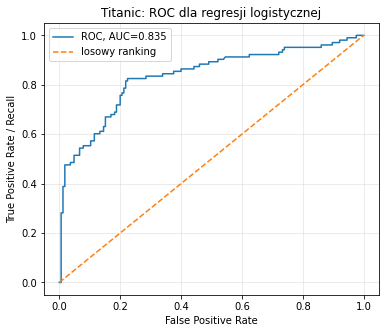

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC, AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="losowy ranking")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Titanic: ROC dla regresji logistycznej")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### AUC jako intuicja rankingowa

AUC można intuicyjnie czytać jako:

> Jak często losowo wybrany przypadek pozytywny ma wyższy score niż losowo wybrany przypadek negatywny?

Czyli AUC nie pyta jeszcze o próg. AUC ocenia ranking.

In [8]:
def auc_pairwise(y_true, score):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    pos = score[y_true == 1]
    neg = score[y_true == 0]
    wins = 0
    ties = 0
    total = len(pos) * len(neg)
    for p in pos:
        wins += np.sum(p > neg)
        ties += np.sum(p == neg)
    return (wins + 0.5 * ties) / total

print("AUC sklearn:", round(roc_auc_score(y_test, proba), 6))
print("AUC ręcznie, pairwise:", round(auc_pairwise(y_test.values, proba), 6))

AUC sklearn: 0.834804
AUC ręcznie, pairwise: 0.834804


## 5. Leakage na Titanicu: bardzo mocny przykład

W zbiorze Titanic jest kolumna `alive`, która jest praktycznie tekstową kopią targetu `survived`.

Jeśli wrzucimy ją jako feature, model będzie wyglądał genialnie, ale tylko dlatego, że dostał odpowiedź w danych wejściowych.

To jest świetny przykład na wykład:

$$
\text{bardzo wysokie AUC} \not\Rightarrow \text{dobry model}
$$

Najpierw pytamy: **czy feature byłby dostępny w chwili predykcji?**

### Leakage: dlaczego `alive` jest zakazane?

`alive` jest tekstową wersją informacji, którą próbujemy przewidzieć (`survived`). Jeśli użyjemy `alive` jako cechy, model dostaje odpowiedź wprost.

To jest dobry przykład zasady:

> Cecha musi być dostępna w momencie predykcji i nie może być przepisaną wersją targetu.

In [9]:
df_leak = df_t.copy()
df_leak["alive_yes_LEAK"] = (titanic["alive"] == "yes").astype(int)
features_leak = features + ["alive_yes_LEAK"]

Xl = df_leak[features_leak]
yl = df_leak["survived"]
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    Xl, yl, test_size=0.30, random_state=42, stratify=yl
)

leaky_model = LogisticRegression(max_iter=5000, C=1e6, solver="lbfgs")
leaky_model.fit(Xl_train, yl_train)
proba_leak = leaky_model.predict_proba(Xl_test)[:, 1]
print("AUC uczciwy model:", round(roc_auc_score(y_test, proba), 4))
print("AUC z leakage:", round(roc_auc_score(yl_test, proba_leak), 4))
print(pd.DataFrame({"feature": features_leak, "beta": leaky_model.coef_[0]}))

AUC uczciwy model: 0.8348
AUC z leakage: 1.0
          feature     beta
0          female   3.2141
1          pclass  -3.7954
2             age  -0.1998
3        fare_log  -0.8433
4       alone_int   2.0398
5  alive_yes_LEAK  35.8277


## 6. Tips: regresja liniowa

Teraz drugi zbiór. Najprostsze pytanie regresyjne:

> Czy na podstawie rachunku `total_bill` możemy przewidzieć napiwek `tip`?

Model:

$$
\widehat{tip}=\beta_0+\beta_1\cdot total\_bill
$$

To jest naturalny przykład do przypomnienia:

- reszt,
- $SSE$,
- $R^2$,
- różnicy między modelem a danymi.

### Tips: wracamy do regresji liniowej

Pytanie:

$$
\widehat{tip}=\beta_0+\beta_1\cdot total\_bill
$$

To jest dobry kontrast z Titanicem: tutaj target `tip` jest ciągły, więc zaczynamy od regresji liniowej, a dopiero potem tworzymy target binarny.

intercept beta0 = 0.9203
slope beta1 = 0.1050
R^2 = 0.4566
RMSE = 1.0179


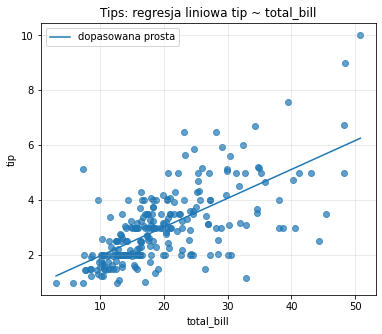

In [10]:
X_bill = tips[["total_bill"]]
y_tip = tips["tip"]
lin = LinearRegression()
lin.fit(X_bill, y_tip)
pred_tip = lin.predict(X_bill)

print(f"intercept beta0 = {lin.intercept_:.4f}")
print(f"slope beta1 = {lin.coef_[0]:.4f}")
print(f"R^2 = {r2_score(y_tip, pred_tip):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_tip, pred_tip)):.4f}")

plt.figure(figsize=(6, 5))
plt.scatter(tips["total_bill"], tips["tip"], alpha=0.7)
order = np.argsort(tips["total_bill"].values)
plt.plot(tips["total_bill"].values[order], pred_tip[order], label="dopasowana prosta")
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.title("Tips: regresja liniowa tip ~ total_bill")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Tips jako klasyfikacja: czy napiwek był duży?

Tworzymy target:

$$
large\_tip = 1 \quad \text{gdy} \quad tip \ge 3.00
$$

W praktyce to jest **decyzja analityczna**. Zmieniamy pytanie z regresji:

> Ile wyniesie napiwek?

na klasyfikację:

> Czy napiwek będzie „duży” według przyjętej definicji?

W tym notebooku `large_tip` oznacza próg kwotowy. Można zrobić alternatywne ćwiczenie z procentem napiwku, np. `tip_pct >= 0.15`.

### Tips jako klasyfikacja: ważna uwaga o definicji targetu

W tej wersji kodu target jest zdefiniowany jako:

$$
large\_tip=I(tip \ge 3.00)
$$

Kolumna `tip_pct = tip / total_bill` jest liczona pomocniczo, ale **nie jest targetem** w tym notebooku. To ważne, bo wcześniejszy opis mógł sugerować próg procentowy. Tutaj pytanie brzmi po prostu:

> Czy napiwek był co najmniej 3 dolary?

To jest decyzja analityczna. Można też zrobić inną wersję ćwiczenia z `tip_pct >= 0.15`.

In [11]:
t = tips.copy()
t["tip_pct"] = t["tip"] / t["total_bill"]
t["large_tip"] = (t["tip"] >= 3.00).astype(int)
t["dinner"] = (t["time"] == "Dinner").astype(int)
t["smoker_yes"] = (t["smoker"] == "Yes").astype(int)
t["weekend"] = t["day"].isin(["Sat", "Sun"]).astype(int)

print(t[["total_bill", "tip", "tip_pct", "large_tip", "size", "dinner", "smoker_yes", "weekend"]].head())
print("\nUdział large_tip:", round(t["large_tip"].mean(), 4))

# odds ratio large_tip: dinner vs lunch
odds_table = pd.crosstab(t["dinner"], t["large_tip"])
odds_table.index = ["Lunch", "Dinner"]
odds_table.columns = ["small_tip", "large_tip"]
print("\nTabela dinner x large_tip")
print(odds_table)

# dodajemy 0.5 tylko jeśli pojawiłyby się zera; tutaj zwykle nie trzeba, ale zostawiamy bezpiecznie
A = odds_table.loc["Dinner", "large_tip"]
B = odds_table.loc["Dinner", "small_tip"]
C = odds_table.loc["Lunch", "large_tip"]
D = odds_table.loc["Lunch", "small_tip"]
OR_dinner = (A * D) / (B * C)
print(f"\nOR large_tip Dinner vs Lunch = {OR_dinner:.4f}")
print(f"log(OR) = {math.log(OR_dinner):.4f}")

   total_bill   tip  tip_pct  large_tip  size  dinner  smoker_yes  weekend
0       16.99  1.01   0.0594          0     2       1           0        1
1       10.34  1.66   0.1605          0     3       1           0        1
2       21.01  3.50   0.1666          1     3       1           0        1
3       23.68  3.31   0.1398          1     2       1           0        1
4       24.59  3.61   0.1468          1     4       1           0        1

Udział large_tip: 0.4959

Tabela dinner x large_tip
        small_tip  large_tip
Lunch          45         23
Dinner         78         98

OR large_tip Dinner vs Lunch = 2.4582
log(OR) = 0.8994


### Model logistyczny dla `large_tip`

Używamy cech, które mogłyby być dostępne przed poznaniem napiwku:

- `total_bill`,
- `size`,
- pora dnia,
- palacz/niepalacz,
- weekend.

Nie używamy `tip`, bo `large_tip` jest zdefiniowane z `tip`. Dodanie `tip` będzie pokazane jako leakage.

In [12]:
features_tips = ["total_bill", "size", "dinner", "smoker_yes", "weekend"]
Xt = t[features_tips]
yt = t["large_tip"]
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    Xt, yt, test_size=0.30, random_state=42, stratify=yt
)

model_tips = LogisticRegression(max_iter=5000, C=1e6, solver="lbfgs")
model_tips.fit(Xt_train, yt_train)
score_tips = model_tips.predict_proba(Xt_test)[:, 1]

print("AUC tips large_tip:", round(roc_auc_score(yt_test, score_tips), 4))
print(pd.DataFrame({
    "feature": ["intercept"] + features_tips,
    "beta_log_odds": [model_tips.intercept_[0]] + list(model_tips.coef_[0]),
    "exp(beta)": np.exp([model_tips.intercept_[0]] + list(model_tips.coef_[0])),
}))

print("\nMetryki przy progach:")
print(pd.DataFrame([metrics_at_threshold(yt_test.values, score_tips, th) for th in [0.3, 0.5, 0.7]]))

AUC tips large_tip: 0.8685
      feature  beta_log_odds  exp(beta)
0   intercept        -4.0737     0.0170
1  total_bill         0.1604     1.1739
2        size         0.2374     1.2680
3      dinner         1.4229     4.1493
4  smoker_yes         0.4942     1.6392
5     weekend        -1.0701     0.3430

Metryki przy progach:
   threshold  TP  FP  TN  FN  accuracy  precision  recall_TPR     FPR      F1
0        0.3  35  17  20   2    0.7432     0.6731      0.9459  0.4595  0.7865
1        0.5  30   9  28   7    0.7838     0.7692      0.8108  0.2432  0.7895
2        0.7  22   4  33  15    0.7432     0.8462      0.5946  0.1081  0.6984


## 8. Leakage w Tips

Jeśli target `large_tip` został zdefiniowany przez `tip`, to nie wolno używać `tip` jako cechy.

W realnym problemie chcemy przewidywać duży napiwek **zanim** poznamy napiwek.

To jest analogiczne do `alive` w Titanicu.

### Leakage w Tips

Jeśli target brzmi:

$$
large\_tip=I(tip \ge 3.00)
$$

to użycie `tip` jako cechy jest przeciekiem. Model nie przewiduje wtedy przyszłości, tylko odczytuje odpowiedź.

In [13]:
features_tips_leak = features_tips + ["tip"]
Xtl = t[features_tips_leak]
Xtl_train, Xtl_test, ytl_train, ytl_test = train_test_split(
    Xtl, yt, test_size=0.30, random_state=42, stratify=yt
)
leaky_tips = LogisticRegression(max_iter=5000, C=1e6, solver="lbfgs")
leaky_tips.fit(Xtl_train, ytl_train)
score_tips_leak = leaky_tips.predict_proba(Xtl_test)[:, 1]
print("AUC bez leakage:", round(roc_auc_score(yt_test, score_tips), 4))
print("AUC z tip jako leakage:", round(roc_auc_score(ytl_test, score_tips_leak), 4))

AUC bez leakage: 0.8685
AUC z tip jako leakage: 0.9993


## 9. Regularizacja na Titanicu: L1 wybiera cechy

Aby pokazać sens regularyzacji, dodamy sztuczne cechy szumowe.

Bez regularyzacji model może próbować dopasowywać przypadkowe wzorce. L1/Lasso ma tendencję do zerowania części współczynników:

$$
\text{loss} + \lambda \sum_j |\beta_j|
$$

W `sklearn` dla regresji logistycznej używa się parametru `C`, gdzie:

$$
C \downarrow \quad \Longleftrightarrow \quad \lambda \uparrow
$$

czyli mniejsze `C` oznacza silniejszą regularyzację.

### L1 regularization i cechy szumowe

Dodajemy 20 losowych cech `noise_00`, ..., `noise_19`. One nie powinny pomagać.

L1 ma tendencję do zerowania współczynników. W tabeli obserwujemy:

- ile współczynników zostało niezerowych,
- ile losowych cech szumowych model nadal zostawił.

Mniejsze `C` oznacza silniejszą regularyzację.

In [14]:
rng = np.random.default_rng(42)
X_noise = X.copy().reset_index(drop=True)
for j in range(20):
    X_noise[f"noise_{j:02d}"] = rng.normal(size=len(X_noise))

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_noise, y.reset_index(drop=True), test_size=0.30, random_state=42, stratify=y
)

import warnings

rows = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=UserWarning)
    for C in [10, 1, 0.3, 0.1, 0.03, 0.01]:
        pipe = make_pipeline(
            StandardScaler(),
            LogisticRegression(penalty="l1", solver="liblinear", C=C, max_iter=5000)
        )
        pipe.fit(Xn_train, yn_train)
        score = pipe.predict_proba(Xn_test)[:, 1]
        coefs = pipe.named_steps["logisticregression"].coef_[0]
        rows.append({
            "C": C,
            "AUC_test": roc_auc_score(yn_test, score),
            "nonzero_coefficients": int(np.sum(np.abs(coefs) > 1e-8)),
            "nonzero_noise_coefficients": int(np.sum(np.abs(coefs[len(features):]) > 1e-8)),
        })

reg_table = pd.DataFrame(rows)
print(reg_table)

       C  AUC_test  nonzero_coefficients  nonzero_noise_coefficients
0  10.00    0.8202                    25                          20
1   1.00    0.8213                    22                          17
2   0.30    0.8252                    19                          14
3   0.10    0.8281                     9                           5
4   0.03    0.8327                     3                           0
5   0.01    0.7580                     1                           0


## Jak używać tego notebooka?

Na wykładzie wystarczy pokazać:

1. Titanic: tabela `sex × survived`, OR i logOR,
2. Titanic: ROC/AUC i leakage,
3. Tips: `tip ~ total_bill` jako krótki powrót do regresji liniowej.

Resztę zostawić na ćwiczenia.

## 10. Propozycje ćwiczeń

### Ćwiczenie 1 — odds ratio z Titanica

Ręcznie policz:

1. prawdopodobieństwo przeżycia kobiet,
2. prawdopodobieństwo przeżycia mężczyzn,
3. odds przeżycia kobiet,
4. odds przeżycia mężczyzn,
5. $OR$ i $\log(OR)$.

Następnie sprawdź, czy $\log(OR)$ zgadza się z różnicą logitów.

### Ćwiczenie 2 — threshold tuning

Dla modelu Titanic zmień próg z $0.5$ na $0.3$ i $0.7$.

Odpowiedz:

- kiedy rośnie recall?
- kiedy rośnie precision?
- który próg wybrałbyś, jeśli false negative jest drogie?

### Ćwiczenie 3 — leakage

W Titanicu dodaj `alive_yes_LEAK`, a w Tips dodaj `tip`.

Odpowiedz:

- dlaczego AUC skacze?
- dlaczego to nie jest dobry model?
- czy taka cecha byłaby dostępna w chwili predykcji?

### Ćwiczenie 4 — mini-projekt

Wybierz jeden problem:

1. Titanic: przewidzieć `survived` i opisać model przez odds ratio, ROC/AUC i threshold.
2. Tips: przewidzieć `tip` regresją liniową oraz `large_tip` regresją logistyczną.
3. Marathon: przewidzieć `under_4h` i porównać model z leakage oraz bez leakage.

W raporcie pokaż:

$$
X\beta \rightarrow \text{score} \rightarrow \text{metryka} \rightarrow \text{decyzja}
$$